# Ornstein–Uhlenbeck perturbations for MPPIv2

`MPPIv2` draws its candidate knot sequences as **iid Gaussian** perturbations of the
nominal — a single line, `analytic_mppi/controllers/mppi_v2.py:50-55`:

```python
noise = self.rng.normal(scale=self.noise_level, size=(K, num_knots, nu))
return self.mean[None, ...] + noise
```

iid noise means neighbouring knots are perturbed independently, and the cubic spline
has to smooth the result out afterwards. An **Ornstein–Uhlenbeck** process along the
knot axis instead produces *temporally correlated* perturbations — the standard
exploration trick from DDPG — and its long-run mean is a free design choice.

This notebook measures whether that helps, over **4 sampling arms × 3 environments
× 4 seeds**, 30 s of simulated time per episode:

| arm | what it draws |
|---|---|
| `gaussian` | stock `MPPIv2`, unchanged — the baseline |
| `ou_nominal` | OU reverting to the nominal knot-by-knot: a zero-mean OU *perturbation* |
| `ou_seqmean` | OU reverting to the **entire nominal control sequence, averaged** (one constant) |
| `ou_prefixmean` | OU whose mean **changes every knot**: the causal prefix average `mean(U[0..t])` |

Every arm overrides `sample_knots()` and nothing else, so clipping, spline
interpolation, rollout, scoring, the softmax update and the warm-start shift are
byte-for-byte identical across arms. Any difference in the charts is attributable to
the sampling distribution alone.

`ou_nominal` is the control arm: it has the same mean as `gaussian` and differs only
in correlation, so it separates the *correlation* effect from the *mean-shift* effect
that `ou_seqmean` and `ou_prefixmean` add on top.

In [1]:
import time
from pathlib import Path

import numpy as np

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2

CACHE = Path("runs") / "ou_mppi"     # per-run .npz results live here

T_MAX = 30.0                          # simulated seconds per episode
SEEDS = (0, 1, 2, 3)
OU_THETA = 0.3                        # OU mean reversion per knot step; 1.0 => iid Gaussian

ARMS = ("gaussian", "ou_nominal", "ou_seqmean", "ou_prefixmean")
ARM_LABEL = {
    "gaussian":      "Gaussian (baseline)",
    "ou_nominal":    "OU, mean = nominal",
    "ou_seqmean":    "OU, mean = sequence avg",
    "ou_prefixmean": "OU, mean = prefix avg",
}
ENV_LABEL = {"hopper": "hopper", "walker": "walker", "g1_standup": "humanoid standup"}

## The OU sampler

The OU arms generate the knot samples **as** an OU path along the knot axis, reverting
to a per-arm mean sequence `mu`:

$$x_0 = \mu_0 + \sigma_0\,\varepsilon, \qquad
  x_t = x_{t-1} + \theta\,(\mu_t - x_{t-1}) + \sigma\,\varepsilon_t$$

with $\sigma_0 = \texttt{noise\_level}$ and

$$\sigma = \texttt{noise\_level}\,\sqrt{\theta\,(2-\theta)}.$$

That choice of $\sigma$ makes the **stationary marginal std exactly `noise_level`**, so
every arm — Gaussian baseline included — draws knots with the same per-knot spread.
The arms therefore differ in *temporal correlation* and *mean placement*, not in raw
sample magnitude, which is what makes the comparison fair. The lag-1 correlation along
the knot axis is $1-\theta$; $\theta = 1$ degenerates exactly to the Gaussian arm and
$\theta \to 0$ to a random walk.

The recursion loops over `num_knots` (6 iterations) and is vectorised over the 256
samples, so the OU arms cost the same per step as the baseline.

In [2]:
def ou_mean_sequence(U: np.ndarray, mean_mode: str) -> np.ndarray:
    """Long-run mean sequence mu (num_knots, nu) that the OU process reverts to.

    U is the nominal knot sequence (the controller's current `mean`).

      "nominal"     mu[t] = U[t]                  -- zero-mean OU about the nominal
      "seqmean"     mu[t] = U.mean(axis=0)        -- the entire sequence, averaged (constant)
      "prefixmean"  mu[t] = U[:t+1].mean(axis=0)  -- causal prefix average, changes per knot
    """
    if mean_mode == "nominal":
        return U
    if mean_mode == "seqmean":
        return np.broadcast_to(U.mean(axis=0), U.shape)
    if mean_mode == "prefixmean":
        n = np.arange(1, U.shape[0] + 1, dtype=np.float64)[:, None]
        return np.cumsum(U, axis=0) / n
    raise ValueError(f"unknown mean_mode {mean_mode!r}")


class OUMPPI(MPPIv2):
    """MPPIv2 with Ornstein-Uhlenbeck perturbations along the knot axis.

    Overrides `sample_knots` and nothing else -- clipping, interpolation, rollout,
    scoring, the softmax update and the warm-start shift are all inherited.
    """

    def __init__(self, *args, mean_mode: str = "nominal", ou_theta: float = OU_THETA, **kwargs):
        super().__init__(*args, **kwargs)
        if mean_mode not in ("nominal", "seqmean", "prefixmean"):
            raise ValueError(f"unknown mean_mode {mean_mode!r}")
        if not 0.0 < ou_theta <= 2.0:
            raise ValueError(f"ou_theta must be in (0, 2], got {ou_theta}")
        self.mean_mode = mean_mode
        self.ou_theta = float(ou_theta)

    def sample_knots(self) -> np.ndarray:
        K, N, nu = self.num_samples, self.num_knots, self.nu
        mu = ou_mean_sequence(self.mean, self.mean_mode)
        theta = self.ou_theta
        sigma = self.noise_level * np.sqrt(theta * (2.0 - theta))

        eps = self.rng.normal(size=(K, N, nu))
        x = np.empty((K, N, nu), dtype=np.float64)
        x[:, 0] = mu[0] + self.noise_level * eps[:, 0]   # start at the stationary marginal
        for t in range(1, N):
            x[:, t] = x[:, t - 1] + theta * (mu[t] - x[:, t - 1]) + sigma * eps[:, t]
        return x


def make_controller(arm, task, backend, seed, cfg):
    """Controller for one arm. `gaussian` is stock MPPIv2, untouched."""
    kwargs = dict(task=task, backend=backend, seed=seed,
                  **{k: v for k, v in cfg.items() if k != "task"})
    if arm == "gaussian":
        return MPPIv2(**kwargs)
    return OUMPPI(mean_mode=arm[len("ou_"):], ou_theta=OU_THETA, **kwargs)

## Verifying the sampler

Before running anything expensive, confirm the sampler is what it claims to be. With
20 000 draws at a fixed nominal `U` we check that:

* the **per-knot marginal std** equals `noise_level` for every arm (the σ calibration
  — this is what makes the arms comparable);
* the **per-knot sample mean** matches the analytically propagated mean. Note that for
  a *time-varying* μ the process mean is not μ itself but its exponential moving
  average, $m_t = (1-\theta)\,m_{t-1} + \theta\,\mu_t$ — that is the correct
  expectation to test against, and only the constant-μ arm has $m = \mu$;
* the **lag-1 correlation** along the knot axis is $1-\theta = 0.70$ for the OU arms
  and $\approx 0$ for the Gaussian baseline (the correlation is actually there);
* $\theta = 1$ reproduces the Gaussian arm's statistics exactly.

In [3]:
_vt = make_task("hopper")
_vb = MujocoBackend(_vt.model_path)
_NL, _N, _K = 0.3, 6, 20_000
_U = np.random.default_rng(7).normal(scale=0.5, size=(_N, _vt.nu))   # non-trivial nominal


def _sampler(arm, theta=OU_THETA):
    kw = dict(task=_vt, backend=_vb, num_samples=_K, noise_level=_NL, temperature=0.05,
              num_knots=_N, plan_horizon=0.8, spline_type="cubic", iterations=1, seed=0)
    c = MPPIv2(**kw) if arm == "gaussian" else OUMPPI(mean_mode=arm[3:], ou_theta=theta, **kw)
    c.mean = _U.copy()
    return c


def _propagated_mean(mu, theta):
    m = np.empty_like(mu)
    m[0] = mu[0]
    for t in range(1, len(mu)):
        m[t] = (1 - theta) * m[t - 1] + theta * mu[t]
    return m


def _lag1(x):
    a, b = x[:, :-1] - x[:, :-1].mean(0), x[:, 1:] - x[:, 1:].mean(0)
    return float(np.mean((a * b).mean(0) / (a.std(0) * b.std(0))))


print(f"{_K:,} draws | num_knots={_N} | noise_level={_NL} | theta={OU_THETA}\n")
print(f"{'arm':16s} {'marginal std':>13s} {'max mean err':>13s} {'lag-1 corr':>11s} {'expected':>9s}")
print("-" * 66)
_ok = True
for _arm in ARMS:
    _x = _sampler(_arm).sample_knots()
    _mu_exp = _U if _arm == "gaussian" else _propagated_mean(ou_mean_sequence(_U, _arm[3:]), OU_THETA)
    _corr_exp = 0.0 if _arm == "gaussian" else 1 - OU_THETA
    _std, _err, _c = _x.std(0).mean(), np.abs(_x.mean(0) - _mu_exp).max(), _lag1(_x)
    print(f"{_arm:16s} {_std:13.4f} {_err:13.4f} {_c:11.4f} {_corr_exp:9.2f}")
    _ok &= abs(_std - _NL) < 0.01 and _err < 0.02 and abs(_c - _corr_exp) < 0.03

_x1 = _sampler("ou_nominal", theta=1.0).sample_knots()
print(f"\ntheta=1 degeneracy: std {_x1.std(0).mean():.4f} (want {_NL}), "
      f"mean err {np.abs(_x1.mean(0) - _U).max():.4f}, lag-1 {_lag1(_x1):+.4f} (want 0)")
_ok &= abs(_x1.std(0).mean() - _NL) < 0.01 and abs(_lag1(_x1)) < 0.03

_mus = {m: ou_mean_sequence(_U, m) for m in ("nominal", "seqmean", "prefixmean")}
print(f"mean modes are distinct: max|nominal-seqmean| = {np.abs(_mus['nominal']-_mus['seqmean']).max():.3f}, "
      f"max|seqmean-prefixmean| = {np.abs(_mus['seqmean']-_mus['prefixmean']).max():.3f}")
print(f"prefixmean's last knot == seqmean (both average the whole sequence): "
      f"{np.allclose(_mus['prefixmean'][-1], _mus['seqmean'][-1])}")

assert _ok, "OU sampler verification FAILED"
print("\nall sampler checks pass")

20,000 draws | num_knots=6 | noise_level=0.3 | theta=0.3

arm               marginal std  max mean err  lag-1 corr  expected
------------------------------------------------------------------
gaussian                0.3002        0.0036     -0.0006      0.00
ou_nominal              0.3006        0.0026      0.7010      0.70
ou_seqmean              0.3006        0.0026      0.7010      0.70
ou_prefixmean           0.3006        0.0026      0.7010      0.70

theta=1 degeneracy: std 0.3002 (want 0.3), mean err 0.0036, lag-1 -0.0006 (want 0)
mean modes are distinct: max|nominal-seqmean| = 0.720, max|seqmean-prefixmean| = 0.259
prefixmean's last knot == seqmean (both average the whole sequence): True

all sampler checks pass


## Environments

Hyperparameters are the values already validated in this repo's notebooks — hopper
from `hopper_waypoint_mppi.ipynb`, the G1 from `humanoid_standup_mppiv2.ipynb`; walker
mirrors hopper since it has no tuned notebook. They are held **fixed across arms**, so
the arms are compared at the baseline's own operating point.

All arms use the normal penalty cost (`use_fpl_cost=False`).

**The G1 needs a scripted collapse first.** Zero control holds the G1 upright — its
position actuators target the `stand` keyframe — so from the default pose "standing up"
is trivial and every arm would look identical. The 3 s hip/knee fold + 2 s settle from
`humanoid_standup_mppiv2.ipynb` drops it flat, and *that* is the state the 30 s episode
starts from. The fold is deterministic, computed once, and excluded from the episode
and from every cost curve.

In [4]:
ENVS = {
    "hopper": dict(task="hopper", num_samples=256, noise_level=0.3, temperature=0.05,
                   num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
    "walker": dict(task="walker", num_samples=256, noise_level=0.3, temperature=0.05,
                   num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
    "g1_standup": dict(task="g1_standup", num_samples=256, noise_level=0.15, temperature=0.05,
                       num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
}


def g1_collapse(backend, fold_t=3.0, settle_t=2.0):
    """Scripted fold that drops the G1 flat (from humanoid_standup_mppiv2.ipynb)."""
    fold = np.zeros(backend.nu)
    fold[[0, 6]] = -1.8      # hip pitch
    fold[[3, 9]] = 2.6       # knees
    fold[[4, 10]] = -0.6     # ankle pitch

    states = []
    n_fold, n_settle = round(fold_t / backend.dt), round(settle_t / backend.dt)
    for step in range(n_fold + n_settle):
        backend.step(fold if step < n_fold else np.zeros(backend.nu))
        states.append(backend.get_state().copy())
    return backend.get_state().copy(), np.asarray(states)


def initial_state(env_name, backend):
    if env_name == "g1_standup":
        return g1_collapse(backend)[0]
    return backend.get_state().copy()

## Episode driver

One closed-loop episode of `round(30 / dt)` steps. Per step we record the **realized**
running cost at the closed-loop state — the same `backend.data` source
`analytic_mppi/run.py:_print_step_costs` reads — plus the per-term breakdown, torso
height, and the wall-clock planning time.

Results are cached to `runs/ou_mppi/{env}_{arm}_seed{n}.npz`, so the plotting cells
below re-run instantly without recomputing the sweep.

In [5]:
def run_episode(env_name, arm, seed, *, t_max=T_MAX, cache_dir=CACHE, use_cache=True, verbose=True):
    """One closed-loop episode; returns a dict of recorded arrays. Cached to .npz."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{env_name}_{arm}_seed{seed}.npz"
    if use_cache and path.exists():
        with np.load(path) as z:
            return {k: z[k] for k in z.files}

    cfg = ENVS[env_name]
    task = make_task(cfg["task"])
    backend = MujocoBackend(task.model_path)
    state0 = initial_state(env_name, backend)

    ctrl = make_controller(arm, task, backend, seed, cfg)
    backend.set_state(state0)
    ctrl.reset()

    cost_terms, plan_times, torso_z = [], [], []
    t_wall = time.perf_counter()
    for _ in range(round(t_max / backend.dt)):
        t0 = time.perf_counter()
        u = ctrl.act(backend.get_state())
        plan_times.append(time.perf_counter() - t0)
        backend.step(u)
        cost_terms.append(task.running_cost_terms(
            np.asarray(backend.data.qpos), np.asarray(backend.data.qvel),
            np.asarray(backend.data.sensordata), np.asarray(u)))
        torso_z.append(float(task._torso_height(np.asarray(backend.data.sensordata))))
    elapsed = time.perf_counter() - t_wall

    cost_terms = np.asarray(cost_terms)                     # (n_steps, n_terms)
    out = dict(cost=cost_terms.sum(axis=-1), cost_terms=cost_terms,
               term_names=np.asarray(task.cost_term_names), torso_z=np.asarray(torso_z),
               plan_times=np.asarray(plan_times), dt=np.asarray(backend.dt),
               wall_seconds=np.asarray(elapsed))
    np.savez_compressed(path, **out)
    if verbose:
        print(f"  {env_name:11s} {arm:14s} seed {seed}  mean cost {out['cost'].mean():10.3f}  "
              f"{1e3 * out['plan_times'].mean():5.1f} ms/step  {elapsed:5.1f}s wall", flush=True)
    return out

## Run the sweep

48 episodes: 3 environments × 4 arms × 4 seeds. From cold this takes **~28 minutes**
(hopper ≈ 5.5 ms/plan-step, walker ≈ 13.7, G1 ≈ 38); from the `runs/ou_mppi/` cache it
returns immediately.

The seed only changes the sampling noise — MuJoCo is deterministic and the G1 collapse
is scripted — which is exactly the axis under test.

In [6]:
results = {}
t0 = time.perf_counter()
for env_name in ENVS:
    for arm in ARMS:
        for seed in SEEDS:
            results[(env_name, arm, seed)] = run_episode(env_name, arm, seed, verbose=False)
print(f"{len(results)} episodes ready in {time.perf_counter() - t0:.1f}s "
      f"(cached in {CACHE})")

DT = {e: float(results[(e, ARMS[0], SEEDS[0])]["dt"]) for e in ENVS}
for e in ENVS:
    n = len(results[(e, ARMS[0], SEEDS[0])]["cost"])
    print(f"  {ENV_LABEL[e]:18s} dt={DT[e]:.3f}s  {n} steps  = {n * DT[e]:.0f}s simulated")

48 episodes ready in 0.0s (cached in runs/ou_mppi)
  hopper             dt=0.020s  1500 steps  = 30s simulated
  walker             dt=0.010s  3000 steps  = 30s simulated
  humanoid standup   dt=0.020s  1500 steps  = 30s simulated


## Results

Colors are the data-viz reference palette's first four categorical slots, used in
their documented order (blue → orange → aqua → yellow): that ordering is the
colorblind-safety mechanism and is published as passing every adjacent-pair gate in
light mode. Slots 3–4 sit below 3:1 contrast on the light surface, so under the
relief rule every figure carries **direct labels** and the numeric table below is the
table view.

One color per arm, held constant across all three figures.

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#c9c8c3"
ARM_COLOR = dict(zip(ARMS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": SECOND, "ytick.color": SECOND,
    "axes.grid": True, "grid.color": MUTED, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False,
})


def stack(env_name, arm, key="cost"):
    """(n_seeds, n_steps) array of `key` for one env/arm."""
    return np.stack([results[(env_name, arm, s)][key] for s in SEEDS])


def time_axis(env_name):
    n = len(results[(env_name, ARMS[0], SEEDS[0])]["cost"])
    return np.arange(1, n + 1) * DT[env_name]


def running_avg(c):
    """Cumulative mean along the last axis -- the average cost up to time t."""
    return np.cumsum(c, axis=-1) / np.arange(1, c.shape[-1] + 1)


def label_ends(ax, entries, x, pad=1.015):
    """Direct end-labels, nudged apart so they never collide.

    A nudged label gets a leader line back to its true end-point, so the label
    never loses its association with the series (the whole point of a direct label).
    """
    entries = sorted(entries, key=lambda e: e[1])
    lo, hi = ax.get_ylim()
    log = ax.get_yscale() == "log"
    span = (np.log10(hi) - np.log10(lo)) if log else (hi - lo)
    min_gap, prev = 0.062 * span, None
    for text, y, color in entries:
        v = np.log10(max(y, lo)) if log else y
        if prev is not None and v - prev < min_gap:
            v = prev + min_gap
        prev = v
        y_lab = 10 ** v if log else v
        ax.plot([x], [y], marker="o", ms=5, color=color, mec=SURFACE, mew=2,
                clip_on=False, zorder=5)
        if abs(y_lab - y) > 1e-9:
            ax.plot([x, x * pad], [y, y_lab], color=color, lw=0.8, alpha=0.5,
                    clip_on=False, zorder=4)
        ax.text(x * pad * 1.006, y_lab, text, color=SECOND, fontsize=8,
                va="center", ha="left")


def legend_row(fig, y=0.995):
    handles = [mpl.lines.Line2D([], [], color=ARM_COLOR[a], lw=2, label=ARM_LABEL[a]) for a in ARMS]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, y),
               ncol=4, fontsize=9, labelcolor=SECOND, handlelength=1.6, columnspacing=1.8)


print("palette:", {ARM_LABEL[a]: ARM_COLOR[a] for a in ARMS})

palette: {'Gaussian (baseline)': '#2a78d6', 'OU, mean = nominal': '#eb6834', 'OU, mean = sequence avg': '#1baf7a', 'OU, mean = prefix avg': '#eda100'}


### 1 — Average cost over the episode

The running average of the realized per-step cost up to time *t*: the "average cost"
the arms are being compared on, and it converges to the episode mean at the right-hand
edge. Line = mean over the 4 seeds; band = min–max across seeds, so a wide band means
the arm is seed-sensitive. **Lower is better.**

The window starts at **t = 1 s**. The average is still computed from t = 0 — nothing is
excluded from the numbers — but the first second is a start transient an order of
magnitude above the steady state and identical across arms, and on a full-range axis it
flattens every curve into the same line.

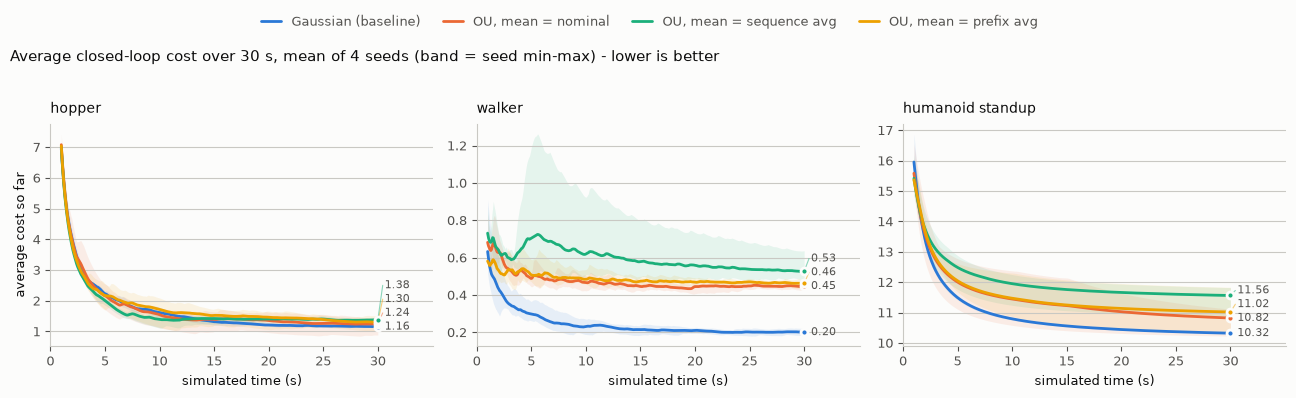

In [8]:
X_START = 1.0   # display window only; the running average is computed from t = 0

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))

for ax, env_name in zip(axes, ENVS):
    t = time_axis(env_name)
    i0 = int(np.searchsorted(t, X_START))
    ends = []
    for arm in ARMS:
        ra = running_avg(stack(env_name, arm))          # (n_seeds, n_steps)
        mean = ra.mean(0)
        ax.fill_between(t[i0:], ra.min(0)[i0:], ra.max(0)[i0:],
                        color=ARM_COLOR[arm], alpha=0.10, lw=0)
        ax.plot(t[i0:], mean[i0:], color=ARM_COLOR[arm])
        ends.append((f"{mean[-1]:,.2f}", mean[-1], ARM_COLOR[arm]))

    ax.set_xlim(X_START, t[-1] * 1.17)
    ax.set_xticks(np.arange(0, t[-1] + 1, 5))          # ticks stop at the data; the rest is label gutter
    ax.set_title(ENV_LABEL[env_name], color=INK, loc="left", pad=8)
    ax.set_xlabel("simulated time (s)")
    ax.grid(axis="x", visible=False)
    label_ends(ax, ends, t[-1])

axes[0].set_ylabel("average cost so far")
legend_row(fig)
fig.suptitle("Average closed-loop cost over 30 s, mean of 4 seeds (band = seed min-max) - lower is better",
             color=INK, fontsize=11, x=0.008, ha="left", y=0.88)
fig.tight_layout(rect=[0, 0, 1, 0.855])
plt.show()

### 2 — Per-step cost trace

Where the running average says *how much*, the raw trace says *when*. Smoothed with a
0.5 s rolling mean (the raw per-step signal at 50–100 Hz is a hairball) and averaged
over seeds. A cost that climbs and stays high is a robot that fell over and did not
recover; a cost that decays to a floor is one holding the target.

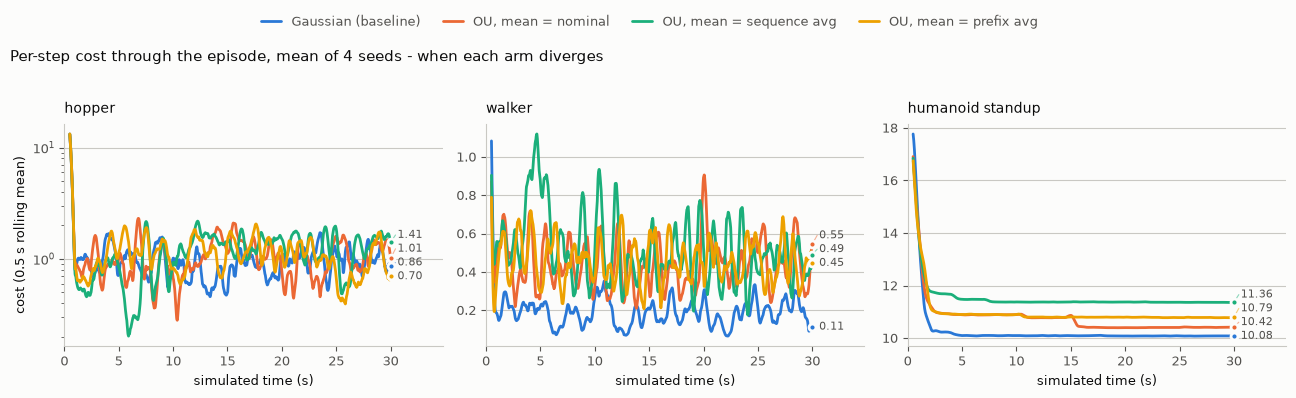

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))


def rolling(c, win):
    k = np.ones(win) / win
    return np.convolve(c, k, mode="valid")


for ax, env_name in zip(axes, ENVS):
    win = max(1, round(0.5 / DT[env_name]))
    t = time_axis(env_name)[win - 1:]
    ends = []
    for arm in ARMS:
        sm = rolling(stack(env_name, arm).mean(0), win)
        ax.plot(t, sm, color=ARM_COLOR[arm])
        ends.append((f"{sm[-1]:,.2f}", sm[-1], ARM_COLOR[arm]))

    hi = max(rolling(stack(env_name, a).mean(0), win).max() for a in ARMS)
    lo = min(rolling(stack(env_name, a).mean(0), win).min() for a in ARMS)
    if hi / max(lo, 1e-9) > 25:
        ax.set_yscale("log")
    ax.set_xlim(0, t[-1] * 1.16)
    ax.set_title(ENV_LABEL[env_name], color=INK, loc="left", pad=8)
    ax.set_xlabel("simulated time (s)")
    ax.grid(axis="x", visible=False)
    label_ends(ax, ends, t[-1])

axes[0].set_ylabel("cost (0.5 s rolling mean)")
legend_row(fig)
fig.suptitle("Per-step cost through the episode, mean of 4 seeds - when each arm diverges",
             color=INK, fontsize=11, x=0.008, ha="left", y=0.88)
fig.tight_layout(rect=[0, 0, 1, 0.855])
plt.show()

### 3 — Episode-mean cost, indexed to the baseline

The three environments' costs differ by orders of magnitude, so each arm's episode-mean
cost is **indexed to that environment's Gaussian baseline = 1.00** — one axis, no
arbitrary second scale.

A dot plot rather than bars: every value sits in a narrow band around 1.0, where bars
anchored at zero would compress the entire result into four indistinguishable blocks.
The diamond is the seed mean, the hollow circles are the four individual seeds. **Left
of the line beats the baseline** — and an arm whose seed dots straddle the line is not
actually separable from it.

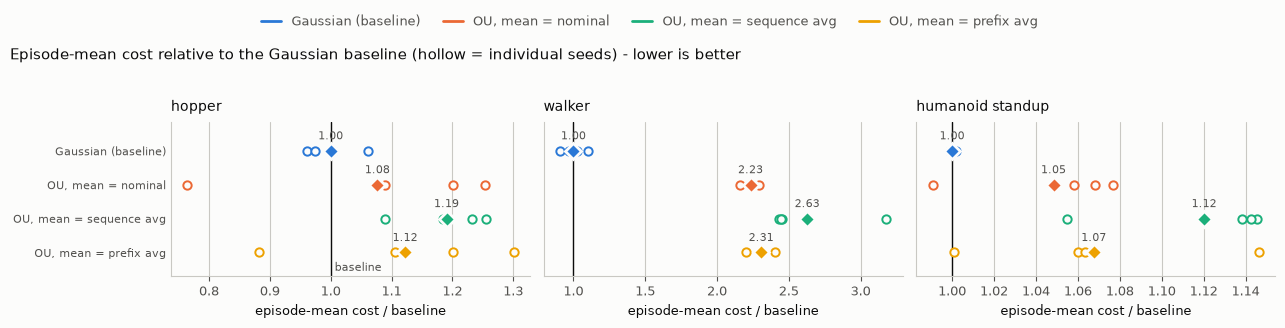

In [10]:
env_list = list(ENVS)
mean_cost = {(e, a): stack(e, a).mean(1) for e in env_list for a in ARMS}   # (n_seeds,)
base = {e: mean_cost[(e, "gaussian")].mean() for e in env_list}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))

for ax, env_name in zip(axes, env_list):
    for ai, arm in enumerate(ARMS):
        rel = mean_cost[(env_name, arm)] / base[env_name]
        y = len(ARMS) - 1 - ai                       # first arm on top
        ax.plot(rel, np.full(len(rel), y), ls="none", marker="o", ms=6,
                mfc=SURFACE, mec=ARM_COLOR[arm], mew=1.4, zorder=3)
        ax.plot([rel.mean()], [y], ls="none", marker="D", ms=8,
                color=ARM_COLOR[arm], mec=SURFACE, mew=2, zorder=4)
        ax.text(rel.mean(), y + 0.26, f"{rel.mean():.2f}", ha="center", va="bottom",
                fontsize=8, color=SECOND, zorder=5)

    ax.axvline(1.0, color=INK, lw=1, zorder=2)
    ax.set_ylim(-0.7, len(ARMS) - 0.15)
    ax.set_yticks(range(len(ARMS)))
    ax.set_yticklabels([ARM_LABEL[a] for a in reversed(ARMS)] if ax is axes[0] else [])
    ax.set_title(ENV_LABEL[env_name], color=INK, loc="left", pad=8)
    ax.set_xlabel("episode-mean cost / baseline")
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)

axes[0].tick_params(axis="y", labelcolor=SECOND, labelsize=8)
axes[0].text(1.0, -0.62, " baseline", color=SECOND, fontsize=8, va="bottom", ha="left")
legend_row(fig)
fig.suptitle("Episode-mean cost relative to the Gaussian baseline (hollow = individual seeds) - lower is better",
             color=INK, fontsize=11, x=0.008, ha="left", y=0.86)
fig.tight_layout(rect=[0, 0, 1, 0.83])
plt.show()

### 4 — The numbers

Episode-mean cost as mean ± std over the 4 seeds, the ratio to the Gaussian baseline,
mean planning time, and — for the humanoid — time to stand, using the same criterion as
`humanoid_standup_mppiv2.ipynb` (first step with torso z ≥ 0.85).

In [11]:
STAND_Z = 0.85


def time_to_stand(env_name, arm, seed):
    r = results[(env_name, arm, seed)]
    hit = np.flatnonzero(r["torso_z"] >= STAND_Z)
    return (hit[0] + 1) * DT[env_name] if hit.size else np.nan


for env_name in env_list:
    print(f"\n{ENV_LABEL[env_name]}   (baseline mean cost = {base[env_name]:,.3f})")
    is_g1 = env_name == "g1_standup"
    head = f"  {'arm':24s} {'mean cost':>18s} {'vs base':>9s} {'ms/step':>9s}"
    print(head + ("   seeds stood / when" if is_g1 else ""))
    print("  " + "-" * (len(head) + (20 if is_g1 else 0)))
    for arm in ARMS:
        mc = mean_cost[(env_name, arm)]
        ms = 1e3 * np.mean([results[(env_name, arm, s)]["plan_times"].mean() for s in SEEDS])
        row = (f"  {ARM_LABEL[arm]:24s} {mc.mean():10,.3f} +/-{mc.std():6.3f} "
               f"{mc.mean() / base[env_name]:9.3f} {ms:9.1f}")
        if is_g1:
            ts = np.array([time_to_stand(env_name, arm, s) for s in SEEDS])
            n_ok = int(np.sum(~np.isnan(ts)))
            # range, not mean -- averaging a 1.4 s stand with a 15.2 s one describes neither
            span = (f"{np.nanmin(ts):.1f}-{np.nanmax(ts):.1f}s" if n_ok > 1 else
                    (f"{np.nanmin(ts):.1f}s" if n_ok else "never"))
            row += f"   {n_ok}/4 {span:>11s}"
        print(row)

best = {e: min(ARMS, key=lambda a: mean_cost[(e, a)].mean()) for e in env_list}
print("\nlowest mean cost per environment:")
for e in env_list:
    print(f"  {ENV_LABEL[e]:18s} {ARM_LABEL[best[e]]}  "
          f"({mean_cost[(e, best[e])].mean() / base[e]:.3f} x baseline)")


hopper   (baseline mean cost = 1.156)
  arm                               mean cost   vs base   ms/step
  -----------------------------------------------------------------
  Gaussian (baseline)           1.156 +/- 0.045     1.000       5.3
  OU, mean = nominal            1.244 +/- 0.219     1.077       5.5
  OU, mean = sequence avg       1.375 +/- 0.073     1.190       5.6
  OU, mean = prefix avg         1.297 +/- 0.179     1.122       5.6

walker   (baseline mean cost = 0.200)
  arm                               mean cost   vs base   ms/step
  -----------------------------------------------------------------
  Gaussian (baseline)           0.200 +/- 0.015     1.000      13.3
  OU, mean = nominal            0.447 +/- 0.010     2.234      13.2
  OU, mean = sequence avg       0.526 +/- 0.064     2.628      13.2
  OU, mean = prefix avg         0.462 +/- 0.014     2.308      13.2

humanoid standup   (baseline mean cost = 10.321)
  arm                               mean cost   vs base   ms

## Conclusion

**Gaussian wins in all three environments. No OU variant beat the baseline anywhere,**
and the ordering is identical in every environment:

$$\texttt{gaussian} \;<\; \texttt{ou\_nominal} \;<\; \texttt{ou\_prefixmean} \;<\; \texttt{ou\_seqmean}$$

| | hopper | walker | humanoid standup |
|---|---|---|---|
| `gaussian` | **1.156** | **0.200** | **10.321** |
| `ou_nominal` | 1.244 (+8%) | 0.447 (+123%) | 10.820 (+5%) |
| `ou_prefixmean` | 1.297 (+12%) | 0.462 (+131%) | 11.018 (+7%) |
| `ou_seqmean` | 1.375 (+19%) | 0.526 (+163%) | 11.562 (+12%) |

**How much of that survives seed noise.** With only 4 seeds, the honest test is whether
the seed *ranges* are disjoint from the baseline's:

* **walker** — all three OU arms are cleanly separated (baseline 0.181–0.221 vs
  `ou_nominal` 0.432–0.459); nothing overlaps. This is a real, large effect.
* **hopper** — only `ou_seqmean` (1.259–1.451) clears the baseline range
  (1.111–1.226). `ou_nominal` spans 0.883–1.448 and straddles it, so hopper is close
  to a wash for the correlation-only arm.
* **humanoid** — by *cost* only `ou_seqmean` separates. But cost badly understates
  what happened here (next point).

**On the humanoid, the cost metric hides a total task failure.** Seeds that stand,
using `humanoid_standup_mppiv2.ipynb`'s criterion (torso z ≥ 0.85):

| arm | stood | when | final torso z |
|---|---|---|---|
| `gaussian` | **4 / 4** | 1.28–1.84 s | 0.949, 0.961, 0.955, 0.957 |
| `ou_nominal` | 2 / 4 | 1.40 s, 15.24 s | 0.951, 0.694, 0.955, 0.683 |
| `ou_prefixmean` | 1 / 4 | 1.96 s | 0.662, 0.691, 0.956, 0.581 |
| `ou_seqmean` | **0 / 4** | never | 0.577, 0.681, 0.579, 0.580 |

`ou_seqmean` fails the task outright on every seed — it never gets off the ground — yet
its cost is only 12% above baseline, because the standup cost is bounded and a humanoid
lying still just accrues a finite penalty rate forever. **Average cost is the wrong
headline for this task**; the stand column is.

**Why correlation alone already hurts.** `ou_nominal` has the *same* mean as the
baseline and the same per-knot marginal std — it differs only in that neighbouring
knots move together — and it is worse in all three environments. The likely mechanism:
with `num_knots = 6` and θ = 0.3 the correlation length is 1/θ ≈ 3.3 knots, so a sample
explores roughly two independent directions along the horizon instead of six. MPPI's
softmax update already averages over samples and the cubic spline already smooths the
result, so the smoothness OU buys was never the binding constraint — the iid draw's
access to knot combinations a correlated draw cannot reach is worth more. (This is an
interpretation consistent with the data, not something these runs isolate directly.)

**Displacing the mean hurts further, and monotonically with the displacement.** The
prefix average sits between the nominal and the full-sequence average by construction —
its first knot is the nominal's, its last is the full-sequence mean — and its cost lands
between those two arms in all three environments. The full-sequence average is the most
displaced and the worst everywhere. That is the expected direction: the warm-started
nominal is already a good iterate, and biasing the sample cloud away from it throws that
information away.

**OU costs nothing to sample.** Planning time is unchanged on hopper (5.3 vs 5.5–5.6
ms/step) and walker (13.3 vs 13.2) — the recursion is vectorised over samples and loops
only over 6 knots. The humanoid's *lower* OU timings (38.8–39.6 vs 43.2 ms/step) are
**not** a speedup: a humanoid lying on the ground has different contact dynamics than
one standing, so MuJoCo's rollouts are cheaper. That number is an artifact of failing
the task, not a benefit of the sampler.

**Caveats.** One θ (0.3), one hyperparameter set per environment, 4 seeds. θ = 1
recovers the Gaussian baseline exactly, and cost rises monotonically as the sampling
mean moves away from the nominal, so a θ sweep would most likely trace a monotone path
between the two rather than find an interior optimum — but that is an extrapolation,
and only a sweep would settle it. The hyperparameters were tuned for the Gaussian
sampler, which is the baseline's home turf; a fair "best-case OU" would retune
`noise_level` and `temperature` per arm.